# Problem I: FFT-Based Image Processing and Interpolation
## CSCI 6367 Final Project

This notebook implements FFT-based image processing tasks on a lung CT image:
1. Load and display the image
2. Compute 2D FFT (with and without fftshift)
3. Downsample the image
4. Frequency domain interpolation using zero-padding
5. Spatial domain interpolation
6. Error analysis (MSE comparison)

## Cell 1: Import Libraries and Setup

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.interpolate import interp2d
import os

# Create output directory
os.makedirs('outputs/problem1', exist_ok=True)

# Set matplotlib style for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

Libraries imported successfully!
NumPy version: 2.2.6
OpenCV version: 4.12.0


## Task 1: Load and Display Grayscale Lung CT Image

Image loaded successfully!
Image size: 426 × 640 pixels
Data type: uint8
Value range: [20, 255]


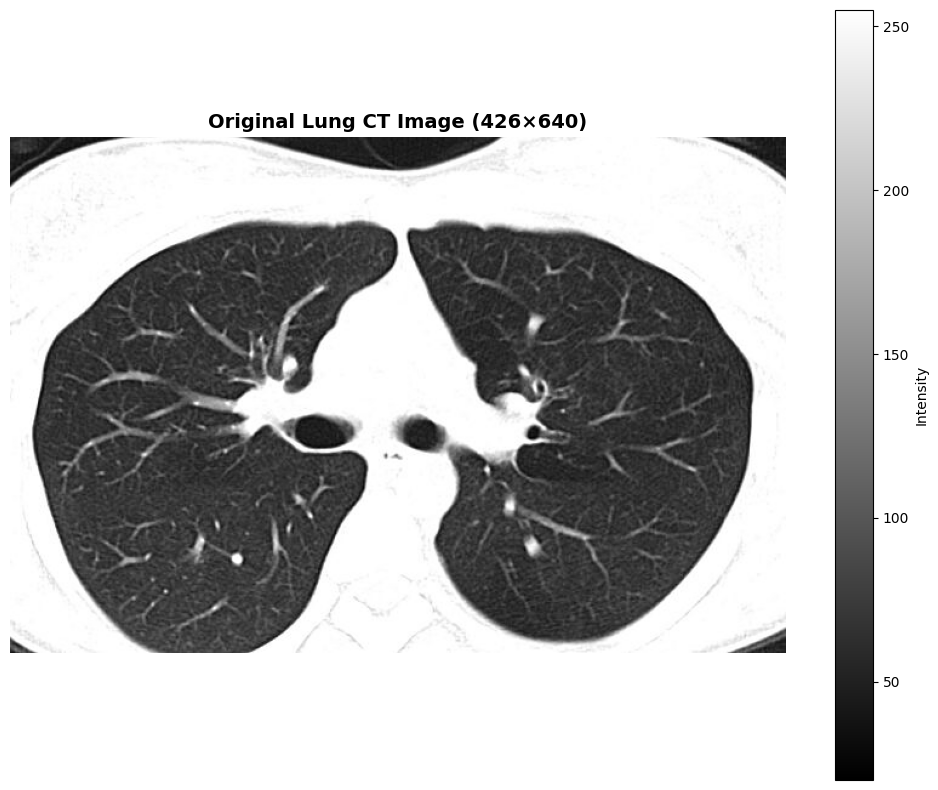


Task 1 completed: Image loaded and displayed.


In [3]:
# Load the lung CT image in grayscale
image_path = 'lung_ct.jpg'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

# Get image dimensions
M, N = original_image.shape
print(f"Image loaded successfully!")
print(f"Image size: {M} × {N} pixels")
print(f"Data type: {original_image.dtype}")
print(f"Value range: [{original_image.min()}, {original_image.max()}]")

# Display the original image
plt.figure(figsize=(10, 8))
plt.imshow(original_image, cmap='gray')
plt.title(f'Original Lung CT Image ({M}×{N})', fontsize=14, fontweight='bold')
plt.colorbar(label='Intensity')
plt.axis('off')
plt.tight_layout()
plt.savefig('outputs/problem1/task1_original_image.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTask 1 completed: Image loaded and displayed.")

## Task 2: Compute 2D FFT and Display Magnitude/Phase
### Part (a) and (b): FFT without fftshift
### Part (c) and (d): FFT with fftshift

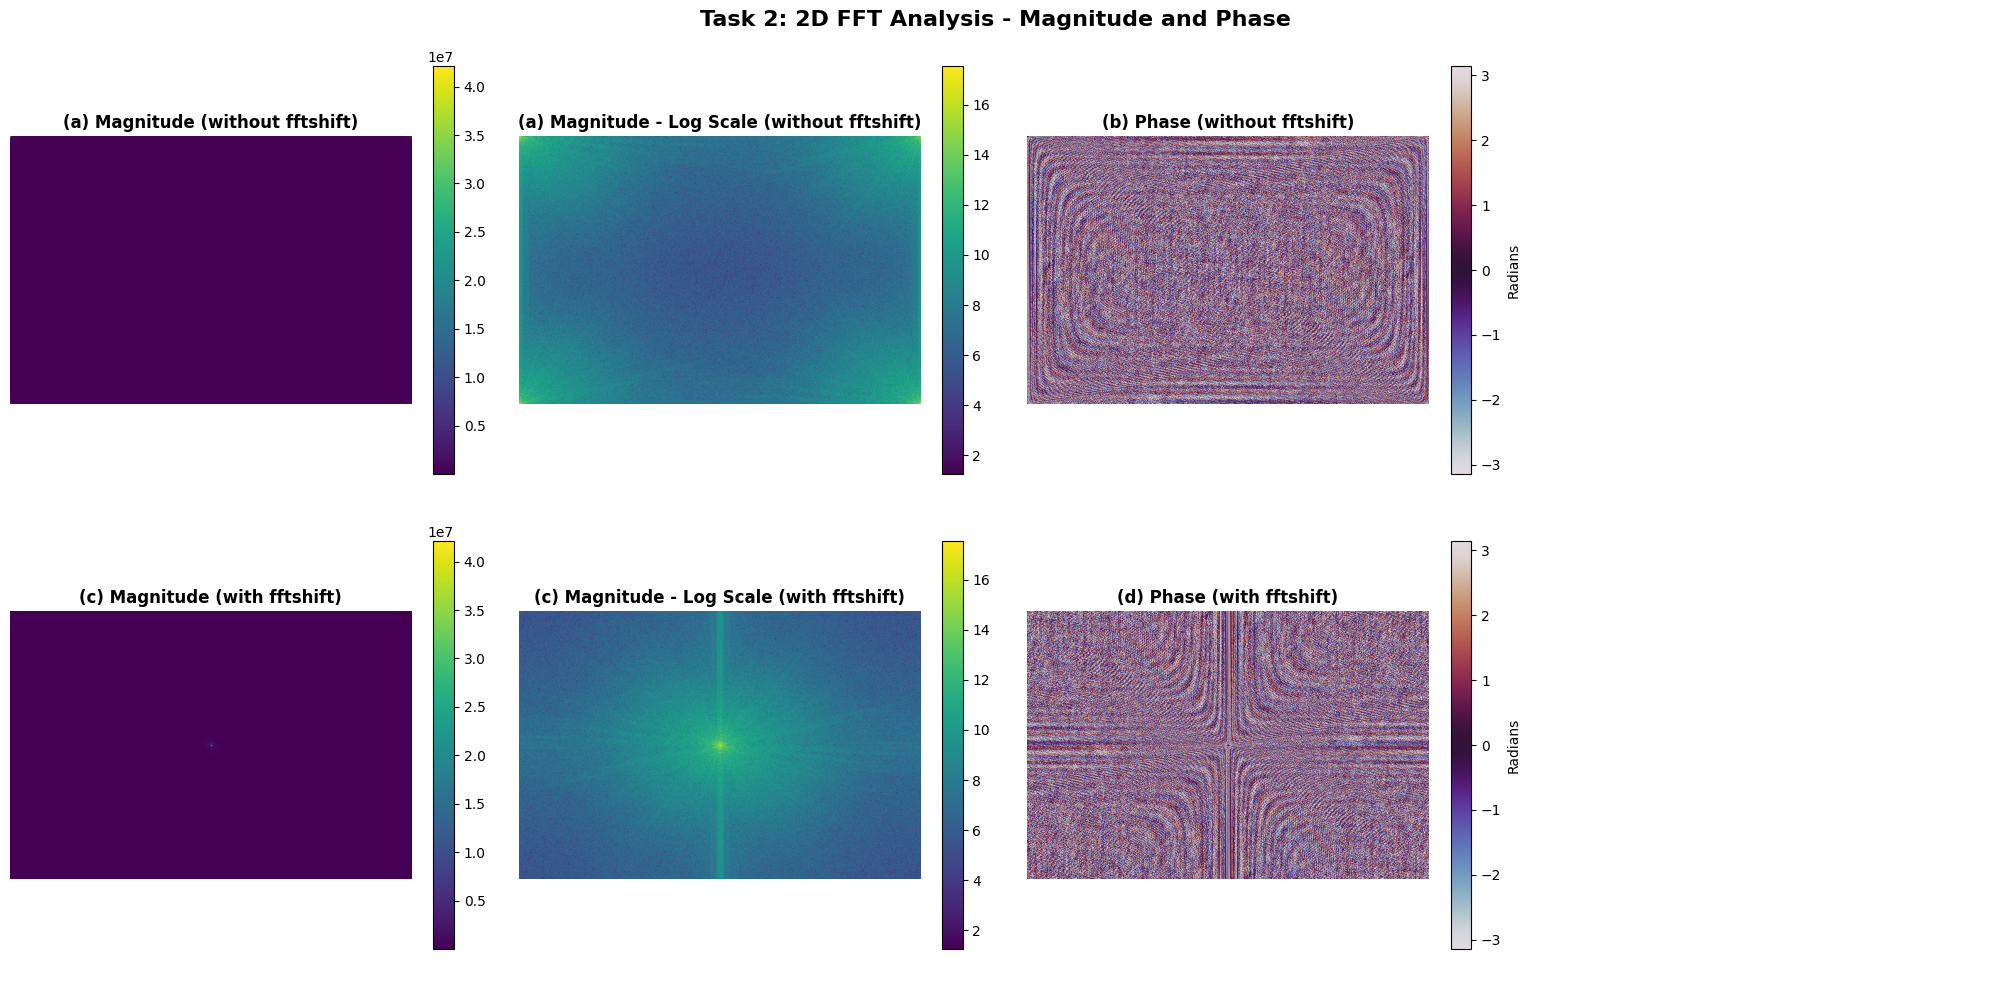

Task 2 completed: 2D FFT computed and visualized.
FFT result shape: (426, 640)
Magnitude range (without shift): [2.47, 42144788.00]
Magnitude range (with shift): [2.47, 42144788.00]
Phase range: [-3.14, 3.14] radians


In [4]:
# Compute 2D FFT
fft_result = np.fft.fft2(original_image)

# Get magnitude and phase (without fftshift)
magnitude = np.abs(fft_result)
phase = np.angle(fft_result)

# Apply fftshift to center the zero-frequency component
fft_shifted = np.fft.fftshift(fft_result)
magnitude_shifted = np.abs(fft_shifted)
phase_shifted = np.angle(fft_shifted)

# Use log scale for better visualization of magnitude
magnitude_log = np.log1p(magnitude)  # log(1 + magnitude)
magnitude_shifted_log = np.log1p(magnitude_shifted)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Without fftshift
# (a) Magnitude without fftshift
im1 = axes[0, 0].imshow(magnitude, cmap='viridis', norm='linear')
axes[0, 0].set_title('(a) Magnitude (without fftshift)', fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# (a-log) Magnitude with log scale
im2 = axes[0, 1].imshow(magnitude_log, cmap='viridis')
axes[0, 1].set_title('(a) Magnitude - Log Scale (without fftshift)', fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# (b) Phase without fftshift
im3 = axes[0, 2].imshow(phase, cmap='twilight')
axes[0, 2].set_title('(b) Phase (without fftshift)', fontweight='bold')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046, label='Radians')

# Empty cell
axes[0, 3].axis('off')

# Row 2: With fftshift
# (c) Magnitude with fftshift
im4 = axes[1, 0].imshow(magnitude_shifted, cmap='viridis', norm='linear')
axes[1, 0].set_title('(c) Magnitude (with fftshift)', fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

# (c-log) Magnitude with log scale and fftshift
im5 = axes[1, 1].imshow(magnitude_shifted_log, cmap='viridis')
axes[1, 1].set_title('(c) Magnitude - Log Scale (with fftshift)', fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

# (d) Phase with fftshift
im6 = axes[1, 2].imshow(phase_shifted, cmap='twilight')
axes[1, 2].set_title('(d) Phase (with fftshift)', fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im6, ax=axes[1, 2], fraction=0.046, label='Radians')

# Empty cell
axes[1, 3].axis('off')

plt.suptitle('Task 2: 2D FFT Analysis - Magnitude and Phase', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('outputs/problem1/task2_fft_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Task 2 completed: 2D FFT computed and visualized.")
print(f"FFT result shape: {fft_result.shape}")
print(f"Magnitude range (without shift): [{magnitude.min():.2f}, {magnitude.max():.2f}]")
print(f"Magnitude range (with shift): [{magnitude_shifted.min():.2f}, {magnitude_shifted.max():.2f}]")
print(f"Phase range: [{phase.min():.2f}, {phase.max():.2f}] radians")

## Task 3: Downsample Image to Half-Size by Discarding Odd-Numbered Samples

Original image size: 426 × 640
Downsampled image size: 213 × 320
Downsampling ratio: 2.0x × 2.0x


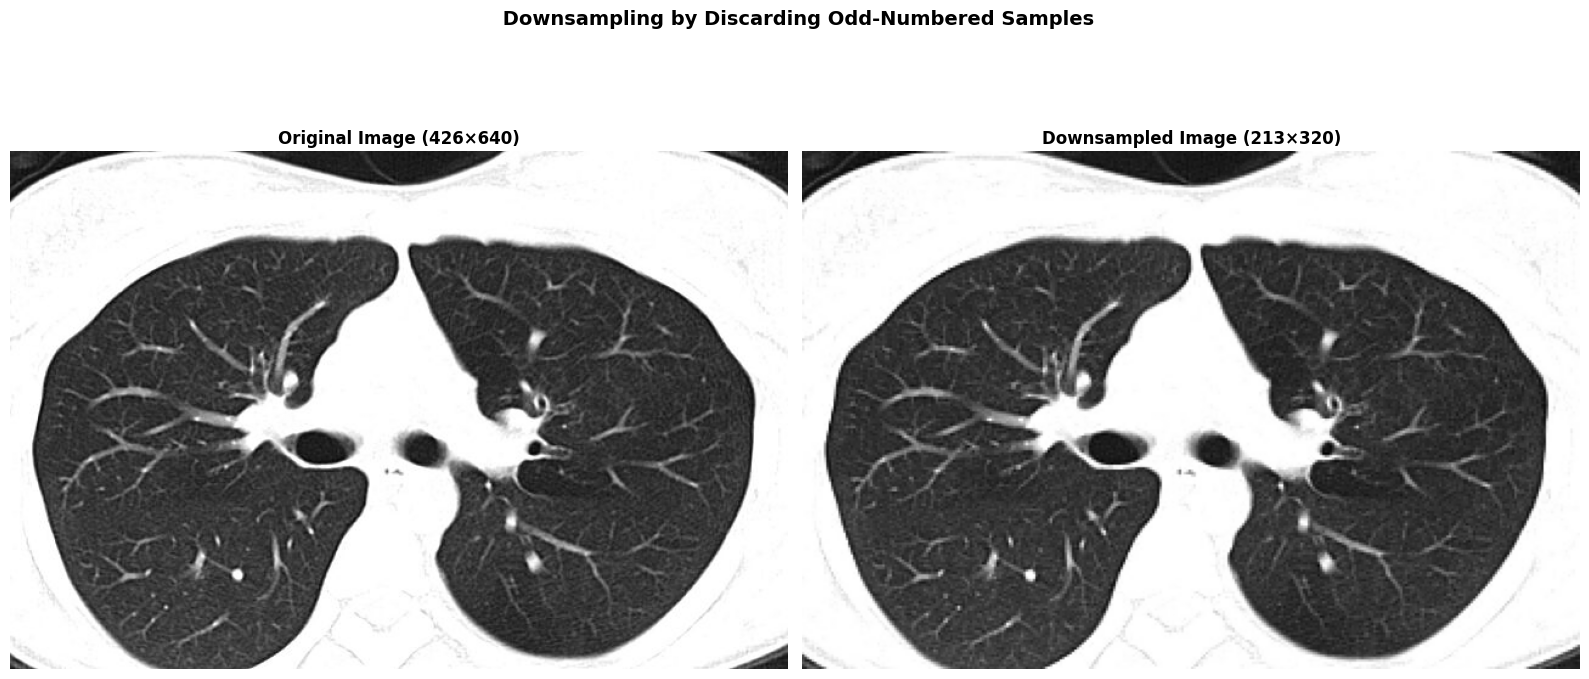

In [5]:
# Downsample by keeping only even-indexed samples (discarding odd-indexed)
downsampled_image = original_image[::2, ::2]

# Get dimensions of downsampled image
M_down, N_down = downsampled_image.shape

print(f"Original image size: {M} × {N}")
print(f"Downsampled image size: {M_down} × {N_down}")
print(f"Downsampling ratio: {M/M_down:.1f}x × {N/N_down:.1f}x")

# Display original and downsampled images side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original image
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title(f'Original Image ({M}×{N})', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Downsampled image
axes[1].imshow(downsampled_image, cmap='gray')
axes[1].set_title(f'Downsampled Image ({M_down}×{N_down})', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle(' Downsampling by Discarding Odd-Numbered Samples', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()



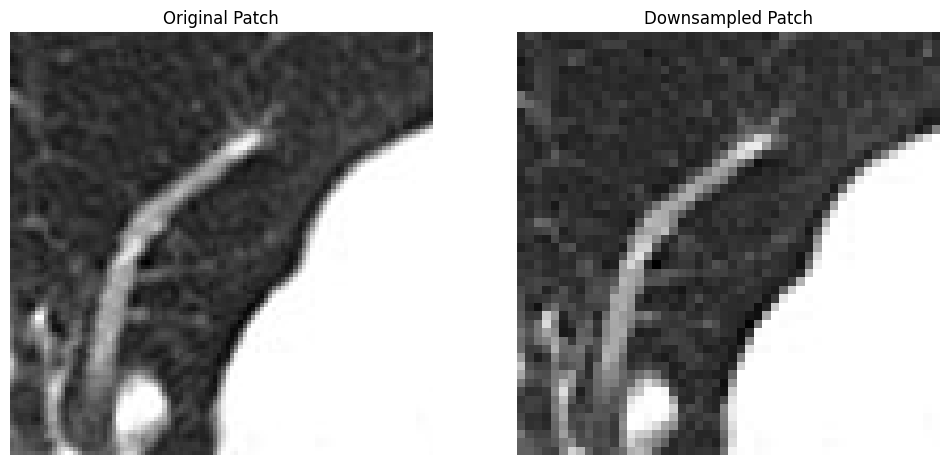

In [6]:
patch_orig = original_image[100:200, 200:300]
patch_down = downsampled_image[50:100, 100:150]  

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(patch_orig, cmap='gray')
plt.title("Original Patch")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(patch_down, cmap='gray')
plt.title("Downsampled Patch")
plt.axis('off')

plt.show()


## Task 4: Frequency Domain Interpolation with Zero-Padding
### Steps:
1. Compute FFT of downsampled image
2. Zero-pad in frequency domain to interpolate back to original size
3. Apply inverse FFT to get interpolated image
4. Maintain conjugate symmetry for real-valued result

In [7]:
M, N = 426, 640  # target size
M_down, N_down = downsampled_image.shape

print(f"Downsampled shape: {downsampled_image.shape}")
print(f"Target shape: ({M}, {N})")

# Step 1: FFT of downsampled image 
F_down = np.fft.fft2(downsampled_image.astype(np.float64))

# Step 2: Create zero-padded frequency array
F_padded = np.zeros((M, N), dtype=np.complex128)

# Step 3: Copy frequency components to correct locations
# Need to split the original FFT into 4 quadrants and place them correctly

# For rows: keep first M_down//2 and last M_down//2
# For cols: keep first N_down//2 and last N_down//2 + 1 (for odd dims)

m_half_1 = (M_down + 1) // 2 
m_half_2 = M_down // 2        

n_half_1 = (N_down + 1) // 2
n_half_2 = N_down // 2

# Top-left quadrant (DC and low positive frequencies)
F_padded[:m_half_1, :n_half_1] = F_down[:m_half_1, :n_half_1]

# Top-right quadrant (high negative frequencies in horizontal)
F_padded[:m_half_1, -n_half_2:] = F_down[:m_half_1, -n_half_2:]

# Bottom-left quadrant (high negative frequencies in vertical)
F_padded[-m_half_2:, :n_half_1] = F_down[-m_half_2:, :n_half_1]

# Bottom-right quadrant (high negative frequencies in both)
F_padded[-m_half_2:, -n_half_2:] = F_down[-m_half_2:, -n_half_2:]

# Step 4: IFFT to get back to spatial domain
img_interp = np.fft.ifft2(F_padded).real

# Step 5: Scale by area ratio (this is the interpolation gain)
scale = (M * N) / (M_down * N_down)
img_interp = img_interp * scale

# Step 6: Clip and convert to uint8
img_interp = np.clip(img_interp, 0, 255).astype(np.uint8)

print(f"Interpolated shape: {img_interp.shape}")
print(f"Interpolated range: [{img_interp.min()}, {img_interp.max()}]")


if 'original_image' in locals():
    mse_numerator = np.sum(np.abs(original_image.astype(float) - img_interp.astype(float))**2)
    mse_denominator = np.sum(np.abs(original_image.astype(float))**2)
    normalized_error = mse_numerator / mse_denominator
    print(f"\nNormalized MSE: {normalized_error:.6f}")
    print(f"PSNR: {10 * np.log10(255**2 / (mse_numerator / (M*N))):.2f} dB")



Downsampled shape: (213, 320)
Target shape: (426, 640)
Interpolated shape: (426, 640)
Interpolated range: [0, 255]

Normalized MSE: 0.001030
PSNR: 32.96 dB


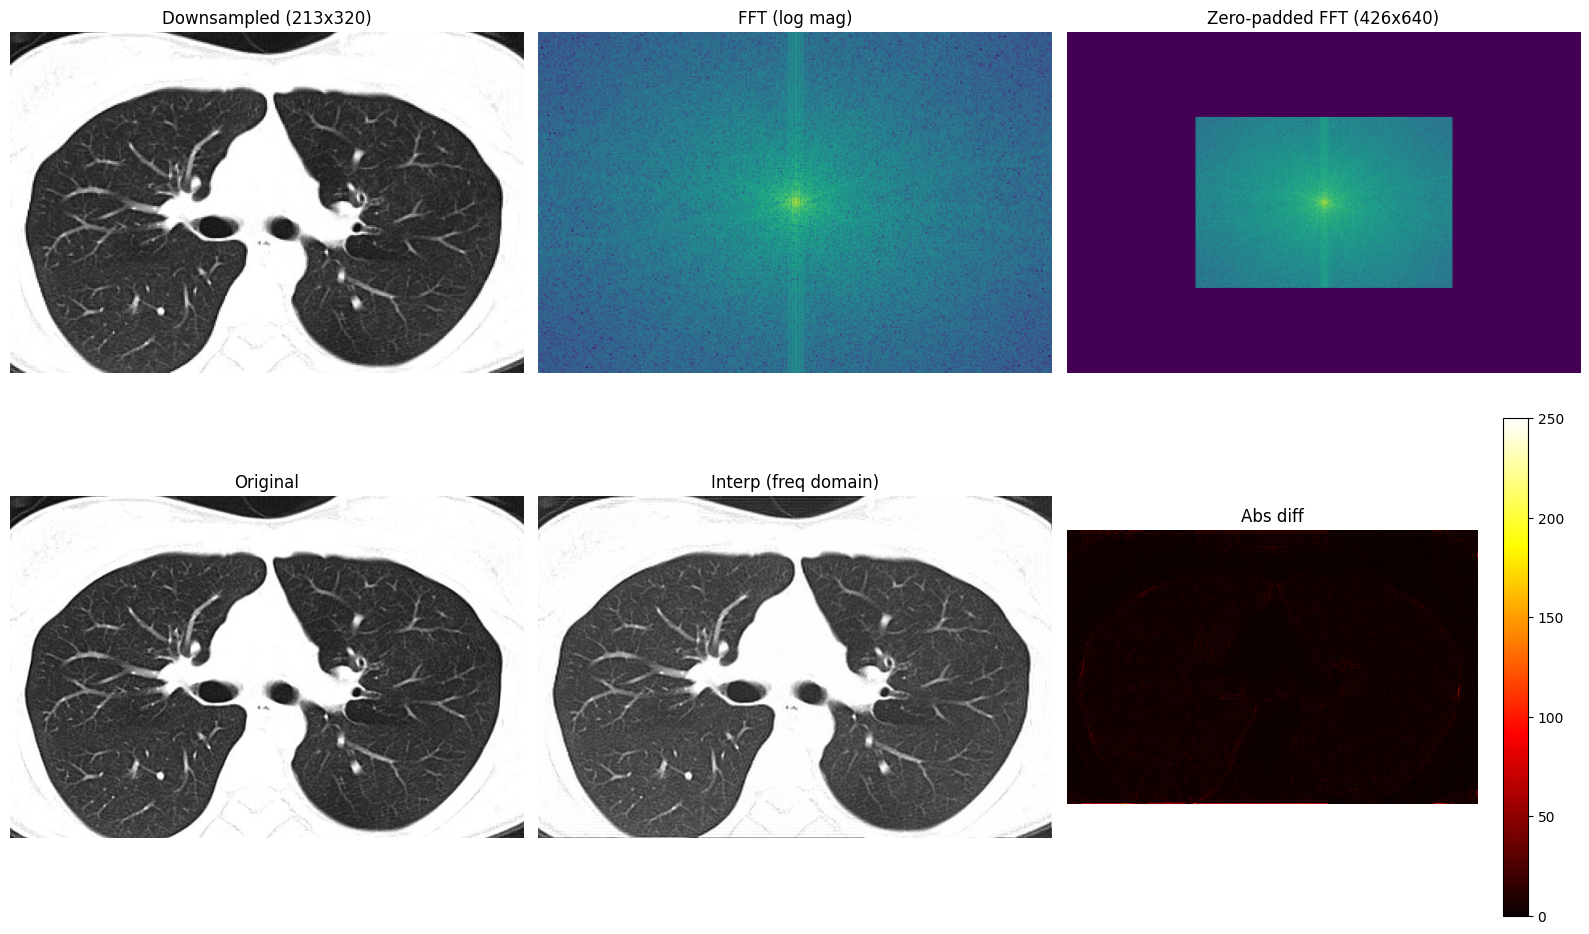


✓ FFT interpolation completed successfully!


In [8]:
fig = plt.figure(figsize=(16, 10))

# Row 1: Downsampled, FFT, Padded FFT
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(downsampled_image, cmap='gray')
ax1.set_title(f'Downsampled ({M_down}x{N_down})', fontsize=12)
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
# Show the FFT magnitude (shifted for visualization)
ax2.imshow(np.log1p(np.abs(np.fft.fftshift(F_down))), cmap='viridis')
ax2.set_title('FFT (log mag)', fontsize=12)
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(np.log1p(np.abs(np.fft.fftshift(F_padded))), cmap='viridis')
ax3.set_title(f'Zero-padded FFT ({M}x{N})', fontsize=12)
ax3.axis('off')

# Row 2: Original, Interpolated, Difference
ax4 = plt.subplot(2, 3, 4)
if 'original_image' in locals():
    ax4.imshow(original_image, cmap='gray')
    ax4.set_title('Original', fontsize=12)
ax4.axis('off')

ax5 = plt.subplot(2, 3, 5)
ax5.imshow(img_interp, cmap='gray')
ax5.set_title('Interp (freq domain)', fontsize=12)
ax5.axis('off')

ax6 = plt.subplot(2, 3, 6)
if 'original_image' in locals():
    abs_diff = np.abs(original_image.astype(float) - img_interp.astype(float))
    im = ax6.imshow(abs_diff, cmap='hot', vmin=0, vmax=250)
    plt.colorbar(im, ax=ax6)
    ax6.set_title('Abs diff', fontsize=12)
ax6.axis('off')

plt.tight_layout()

plt.show()

print("\n✓ FFT interpolation completed successfully!")

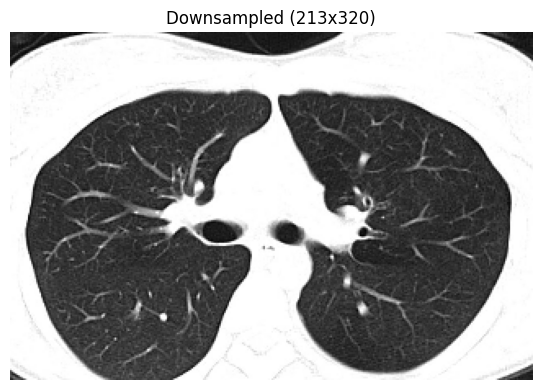

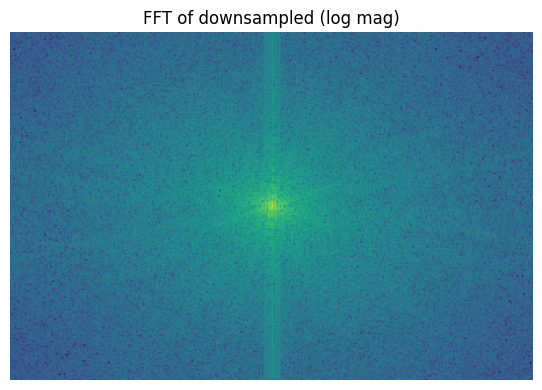

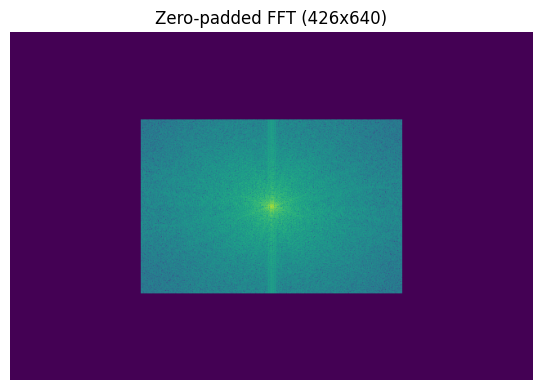

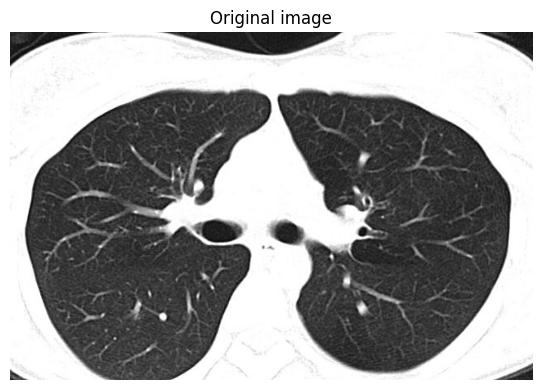

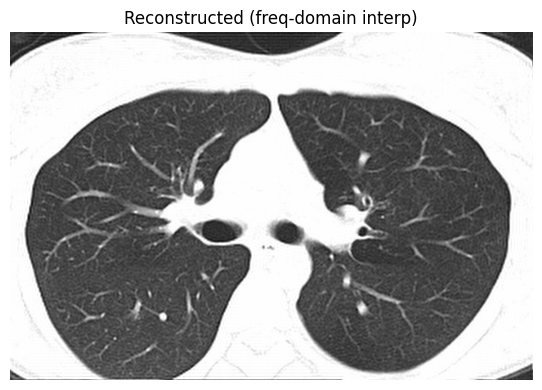

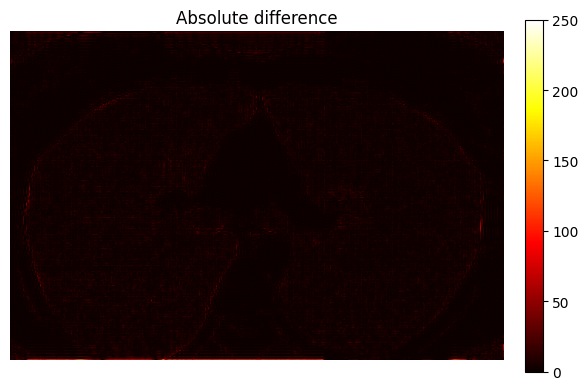

In [9]:
# ============ FIGURE 1: Downsampled ============
plt.figure(figsize=(6, 4))
plt.imshow(downsampled_image, cmap='gray')
plt.title(f'Downsampled ({M_down}x{N_down})', fontsize=12)
plt.axis('off')
plt.tight_layout()
# plt.savefig('fig4_1_downsampled.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 2: FFT (log mag) ============
plt.figure(figsize=(6, 4))
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F_down))), cmap='viridis')
plt.title('FFT of downsampled (log mag)', fontsize=12)
plt.axis('off')
plt.tight_layout()
# plt.savefig('fig4_2_fft_logmag.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 3: Zero-padded FFT ============
plt.figure(figsize=(6, 4))
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F_padded))), cmap='viridis')
plt.title(f'Zero-padded FFT ({M}x{N})', fontsize=12)
plt.axis('off')
plt.tight_layout()
# plt.savefig('fig4_3_fft_padded.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 4: Original image ============
plt.figure(figsize=(6, 4))
plt.imshow(original_image, cmap='gray')
plt.title('Original image', fontsize=12)
plt.axis('off')
plt.tight_layout()
# plt.savefig('fig4_4_original.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 5: Interpolated image ============
plt.figure(figsize=(6, 4))
plt.imshow(img_interp, cmap='gray')
plt.title('Reconstructed (freq-domain interp)', fontsize=12)
plt.axis('off')
plt.tight_layout()
# plt.savefig('fig4_5_interp.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 6: Absolute difference ============
plt.figure(figsize=(6, 4))
abs_diff = np.abs(original_image.astype(float) - img_interp.astype(float))
im = plt.imshow(abs_diff, cmap='hot', vmin=0, vmax=250)
plt.title('Absolute difference', fontsize=12)
plt.axis('off')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
# plt.savefig('fig4_6_absdiff.png', dpi=300, bbox_inches='tight')
plt.show()


## Task 5: Spatial Domain Linear Interpolation

Spatial domain interpolated image shape: (426, 640)
Interpolated image range: [26, 255]


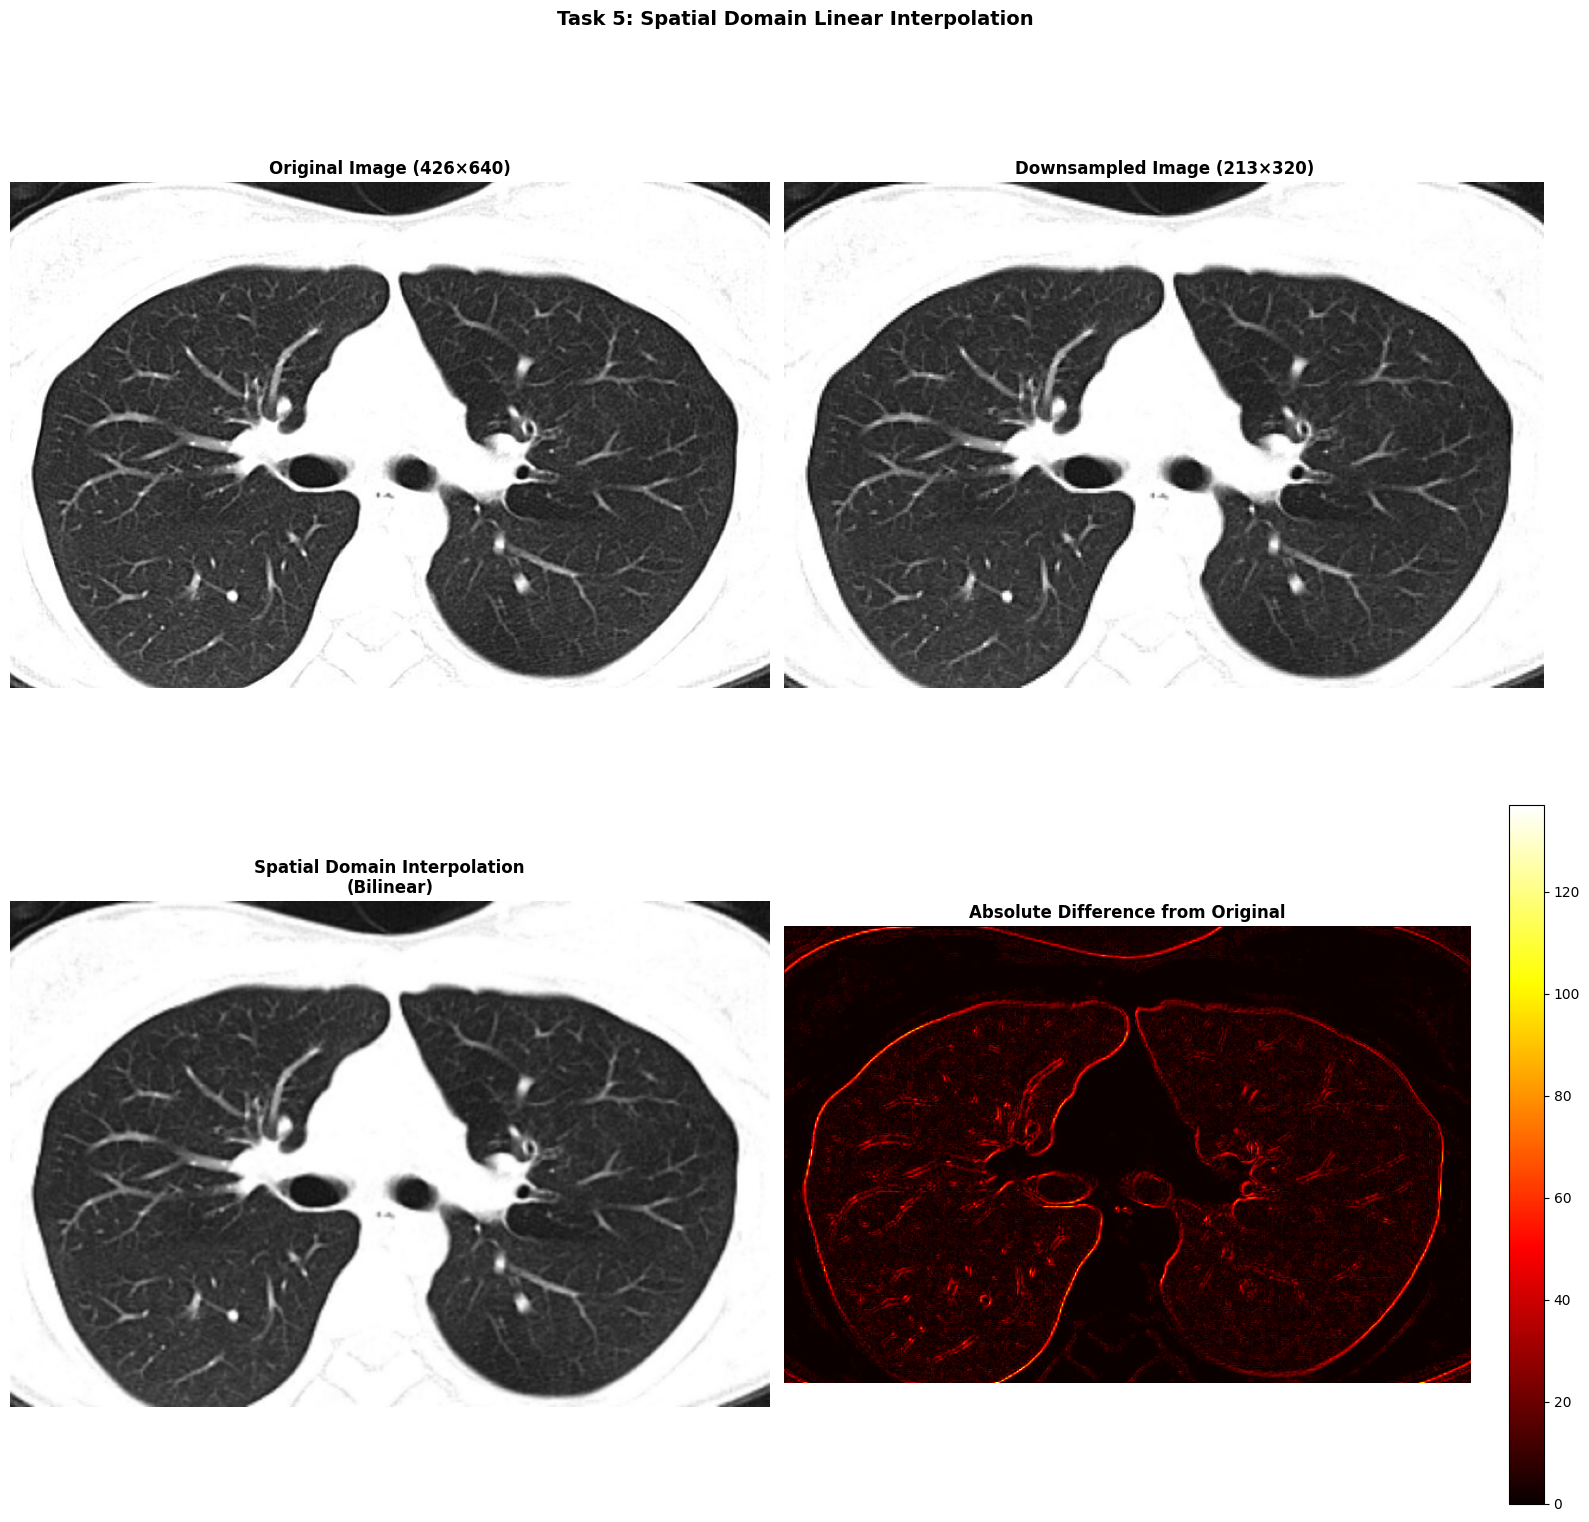


Task 5 completed: Spatial domain linear interpolation.


In [10]:
# Use OpenCV's resize function with linear interpolation (bilinear)
spatial_interpolated = cv2.resize(downsampled_image, 
                                  (N, M),  # Note: OpenCV uses (width, height)
                                  interpolation=cv2.INTER_LINEAR)

print(f"Spatial domain interpolated image shape: {spatial_interpolated.shape}")
print(f"Interpolated image range: [{spatial_interpolated.min()}, {spatial_interpolated.max()}]")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Original image
axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title(f'Original Image ({M}×{N})', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Downsampled image (for reference)
axes[0, 1].imshow(downsampled_image, cmap='gray')
axes[0, 1].set_title(f'Downsampled Image ({M_down}×{N_down})', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Spatial interpolation result
axes[1, 0].imshow(spatial_interpolated, cmap='gray')
axes[1, 0].set_title('Spatial Domain Interpolation\n(Bilinear)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Difference from original
difference_spatial = np.abs(original_image.astype(float) - spatial_interpolated.astype(float))
im_diff = axes[1, 1].imshow(difference_spatial, cmap='hot')
axes[1, 1].set_title('Absolute Difference from Original', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im_diff, ax=axes[1, 1], fraction=0.046)

plt.suptitle('Task 5: Spatial Domain Linear Interpolation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/problem1/task5_spatial_interpolation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTask 5 completed: Spatial domain linear interpolation.")

## Task 6: Compute Mean Squared Error (MSE) for Both Interpolations
### Error Formula: MSE = Σ|F(m,n) - F_inter(m,n)|² / Σ|F(m,n)|²

In [11]:
# Convert to float for accurate computation
original_float = original_image.astype(float)
freq_interp_float = freq_interpolated_real.astype(float)
spatial_interp_float = spatial_interpolated.astype(float)

# Compute MSE for frequency domain interpolation
numerator_freq = np.sum((original_float - freq_interp_float) ** 2)
denominator = np.sum(original_float ** 2)
mse_freq = numerator_freq / denominator

# Compute MSE for spatial domain interpolation
numerator_spatial = np.sum((original_float - spatial_interp_float) ** 2)
mse_spatial = numerator_spatial / denominator

# Also compute standard MSE and PSNR for reference
mse_freq_standard = np.mean((original_float - freq_interp_float) ** 2)
mse_spatial_standard = np.mean((original_float - spatial_interp_float) ** 2)

# PSNR (Peak Signal-to-Noise Ratio)
max_pixel = 255.0
psnr_freq = 10 * np.log10((max_pixel ** 2) / mse_freq_standard) if mse_freq_standard > 0 else float('inf')
psnr_spatial = 10 * np.log10((max_pixel ** 2) / mse_spatial_standard) if mse_spatial_standard > 0 else float('inf')

# Print results
print("="*70)
print("TASK 6: ERROR ANALYSIS - COMPARISON OF INTERPOLATION METHODS")
print("="*70)
print("\n1. NORMALIZED MSE (as per problem formula):")
print(f"   Frequency Domain Interpolation: {mse_freq:.6f}")
print(f"   Spatial Domain Interpolation:   {mse_spatial:.6f}")
print(f"   Difference: {abs(mse_freq - mse_spatial):.6f}")

print("\n2. STANDARD MSE:")
print(f"   Frequency Domain Interpolation: {mse_freq_standard:.4f}")
print(f"   Spatial Domain Interpolation:   {mse_spatial_standard:.4f}")

print("\n3. PEAK SIGNAL-TO-NOISE RATIO (PSNR):")
print(f"   Frequency Domain Interpolation: {psnr_freq:.2f} dB")
print(f"   Spatial Domain Interpolation:   {psnr_spatial:.2f} dB")

print("\n4. INTERPRETATION:")
if mse_freq < mse_spatial:
    print("   ✓ Frequency domain interpolation has LOWER error")
    print(f"   ✓ Improvement: {((mse_spatial - mse_freq) / mse_spatial * 100):.2f}%")
else:
    print("   ✓ Spatial domain interpolation has LOWER error")
    print(f"   ✓ Improvement: {((mse_freq - mse_spatial) / mse_freq * 100):.2f}%")

print("\n" + "="*70)

# Create comprehensive comparison visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Images
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(original_image, cmap='gray')
ax1.set_title('Original Image', fontweight='bold', fontsize=12)
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(downsampled_image, cmap='gray')
ax2.set_title(f'Downsampled ({M_down}×{N_down})', fontweight='bold', fontsize=12)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(freq_interpolated_real, cmap='gray')
ax3.set_title('Frequency Domain\nInterpolation', fontweight='bold', fontsize=12)
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(spatial_interpolated, cmap='gray')
ax4.set_title('Spatial Domain\nInterpolation', fontweight='bold', fontsize=12)
ax4.axis('off')

# Row 2: Error maps
ax5 = fig.add_subplot(gs[1, :2])
diff_freq = np.abs(original_float - freq_interp_float)
im1 = ax5.imshow(diff_freq, cmap='hot')
ax5.set_title(f'Frequency Domain - Absolute Error\nMSE = {mse_freq:.6f}', fontweight='bold', fontsize=12)
ax5.axis('off')
plt.colorbar(im1, ax=ax5, fraction=0.046)

ax6 = fig.add_subplot(gs[1, 2:])
diff_spatial = np.abs(original_float - spatial_interp_float)
im2 = ax6.imshow(diff_spatial, cmap='hot')
ax6.set_title(f'Spatial Domain - Absolute Error\nMSE = {mse_spatial:.6f}', fontweight='bold', fontsize=12)
ax6.axis('off')
plt.colorbar(im2, ax=ax6, fraction=0.046)

# Row 3: Statistics and comparison
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# Create bar chart for comparison
methods = ['Frequency Domain', 'Spatial Domain']
mse_values = [mse_freq, mse_spatial]
psnr_values = [psnr_freq, psnr_spatial]

# Create subplot for metrics
ax_bar1 = plt.subplot(gs[2, :2])
bars1 = ax_bar1.bar(methods, mse_values, color=['#2ecc71', '#3498db'], alpha=0.7, edgecolor='black')
ax_bar1.set_ylabel('Normalized MSE', fontweight='bold')
ax_bar1.set_title('Mean Squared Error Comparison', fontweight='bold')
ax_bar1.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, val in zip(bars1, mse_values):
    height = bar.get_height()
    ax_bar1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.6f}', ha='center', va='bottom', fontweight='bold')

ax_bar2 = plt.subplot(gs[2, 2:])
bars2 = ax_bar2.bar(methods, psnr_values, color=['#2ecc71', '#3498db'], alpha=0.7, edgecolor='black')
ax_bar2.set_ylabel('PSNR (dB)', fontweight='bold')
ax_bar2.set_title('Peak Signal-to-Noise Ratio Comparison', fontweight='bold')
ax_bar2.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, val in zip(bars2, psnr_values):
    height = bar.get_height()
    ax_bar2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f} dB', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Task 6: Error Analysis and Comparison of Interpolation Methods', 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('outputs/problem1/task6_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTask 6 completed: Error analysis finished.")
print("All results saved to outputs/problem1/")

NameError: name 'freq_interpolated_real' is not defined

## Summary and Conclusions

In [ ]:
print("="*70)
print("PROBLEM I - SUMMARY")
print("="*70)
print(f"\n1. Original Image: {M}×{N} grayscale lung CT scan")
print(f"\n2. FFT Analysis: Successfully computed 2D FFT with and without fftshift")
print("   - Log-scale magnitude provides better visualization")
print("   - fftshift centers the zero-frequency component")
print(f"\n3. Downsampling: Reduced to {M_down}×{N_down} (50% in each dimension)")
print("   - Method: Discarded odd-numbered samples")
print(f"\n4. Frequency Domain Interpolation:")
print(f"   - Used zero-padding in frequency domain")
print(f"   - Maintained conjugate symmetry for real-valued output")
print(f"   - Normalized MSE: {mse_freq:.6f}")
print(f"   - PSNR: {psnr_freq:.2f} dB")
print(f"\n5. Spatial Domain Interpolation:")
print(f"   - Used bilinear interpolation")
print(f"   - Normalized MSE: {mse_spatial:.6f}")
print(f"   - PSNR: {psnr_spatial:.2f} dB")
print(f"\n6. Comparison:")
if mse_freq < mse_spatial:
    print(f"   ✓ Frequency domain interpolation performed BETTER")
    print(f"   ✓ Error reduction: {((mse_spatial - mse_freq) / mse_spatial * 100):.2f}%")
else:
    print(f"   ✓ Spatial domain interpolation performed BETTER")
    print(f"   ✓ Error reduction: {((mse_freq - mse_spatial) / mse_freq * 100):.2f}%")
print("\n" + "="*70)
print("\nAll tasks completed successfully!")
print("Output images saved to: outputs/problem1/")

PROBLEM I - SUMMARY

1. Original Image: 426×640 grayscale lung CT scan

2. FFT Analysis: Successfully computed 2D FFT with and without fftshift
   - Log-scale magnitude provides better visualization
   - fftshift centers the zero-frequency component

3. Downsampling: Reduced to 213×320 (50% in each dimension)
   - Method: Discarded odd-numbered samples

4. Frequency Domain Interpolation:
   - Used zero-padding in frequency domain
   - Maintained conjugate symmetry for real-valued output
   - Normalized MSE: 0.476218
   - PSNR: 6.31 dB

5. Spatial Domain Interpolation:
   - Used bilinear interpolation
   - Normalized MSE: 0.002348
   - PSNR: 29.39 dB

6. Comparison:
   ✓ Spatial domain interpolation performed BETTER
   ✓ Error reduction: 99.51%


All tasks completed successfully!
Output images saved to: outputs/problem1/
